### Luke Lawrence HW4
## Preprocessing and Random Forests on Messy Data

In [161]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

## Part 1: Inspecting the Data

1. The raw dataset has **584** rows and **15** columns.
2. The target variable is **"target"**
3. The target classes are **"good_credit"** and **"bad_credit"**
4. The numeric columns are **['age', 'annual_income', 'employment_length_years', 'loan_amount', 'duration_months', 'missed_payments']**
5. The categorical columns are **['applicant_id', 'employment_status', 'loan_purpose', 'checking_status', 'savings_status', 'credit_history', 'housing', 'final_decision_code', 'target']**
6. Missing or suspicious values include real NaN values plus string-coded missing values such as **"?", "unknown", and "na"**. Some numeric columns also contain formatting issues such as **dollar signs, commas, and marking dollar amounts with "k" notation**.
7. There are 24 identically duplicated rows.
8. **"final_decision_code"** is likely leakage-like because it sounds like a decision made after the loan application was evaluated. It should not be used as a feature when predicting "target".


In [162]:
df = pd.read_csv("messy_loan_risk_homework4.csv", dtype=str)

print("Shape:", df.shape)
print("\n Columns:")
print(df.columns.tolist())

target_col = "target"
print("Target variable:", target_col)
print("Target classes:\n", df[target_col])

numeric_cols = [
    "age",
    "annual_income",
    "employment_length_years",
    "loan_amount",
    "duration_months",
    "missed_payments"
]

categorical_cols = [col for col in df.columns if col not in numeric_cols]
print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("\nExactly duplicated rows:", df.duplicated().sum())

Shape: (584, 15)

 Columns:
['applicant_id', 'age', 'annual_income', 'employment_status', 'employment_length_years', 'loan_amount', 'loan_purpose', 'duration_months', 'checking_status', 'savings_status', 'credit_history', 'missed_payments', 'housing', 'final_decision_code', 'target']
Target variable: target
Target classes:
 0       bad_credit
1      good_credit
2      good_credit
3      good_credit
4       bad_credit
          ...     
579    good_credit
580    good_credit
581     bad_credit
582    good_credit
583    good_credit
Name: target, Length: 584, dtype: object

Numeric columns: ['age', 'annual_income', 'employment_length_years', 'loan_amount', 'duration_months', 'missed_payments']
Categorical columns: ['applicant_id', 'employment_status', 'loan_purpose', 'checking_status', 'savings_status', 'credit_history', 'housing', 'final_decision_code', 'target']

Exactly duplicated rows: 24


In [163]:
general_missing_tokens = {"", "?", "na", "n/a", "nan", "null", "unknown"}

def normalized_string(s):
    if pd.isna(s):
        return np.nan
    #strip string of whitespace and then turn to lowercase
    return str(s).strip().lower()

suspicious_report = {}

for col in df.columns:
    #from pandas.DataFrame.map - applies a function to a DataFrame elementwise.
    normalized = df[col].map(normalized_string)
    suspicious_case = normalized.isna() | normalized.isin(general_missing_tokens)
    suspicious_report[col] = {
        "NaN_or_suspicious_count": int(suspicious_case.sum()),
        "suspicious_values": sorted(normalized[suspicious_case].dropna().unique().tolist())
    }

#transpose for readability
suspicious_summary = pd.DataFrame(suspicious_report).T
suspicious_summary

,NaN_or_suspicious_count,suspicious_values
applicant_id,0,[]
age,15,"[?, na, unknown]"
annual_income,37,"[?, na, unknown]"
employment_status,21,"[?, na, unknown]"
employment_length_years,26,"[?, na, unknown]"
loan_amount,27,"[?, na, unknown]"
loan_purpose,13,"[?, na, unknown]"
duration_months,16,"[?, na, unknown]"
checking_status,42,"[?, na, unknown]"
savings_status,46,"[?, na, unknown]"


In [164]:
suspicious_locations = []

for row_index, row in df.iterrows():
    for col in df.columns:
        value = row[col]
        norm = normalized_string(value)
        if pd.isna(norm) or norm in general_missing_tokens:
            suspicious_locations.append({
                "row_index": row_index,
                "column": col,
                "value": value
            })
            
suspicious_locations_df = pd.DataFrame(suspicious_locations)
suspicious_locations_df.head(50).T

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
row_index,1,5,12,17,18,18,19,19,20,21,...,84,87,90,91,95,96,96,98,99,102
column,loan_purpose,annual_income,savings_status,checking_status,loan_amount,savings_status,age,annual_income,final_decision_code,age,...,employment_status,age,employment_status,annual_income,annual_income,savings_status,credit_history,annual_income,missed_payments,annual_income
value,unknown,na,NaN,NaN,?,NaN,unknown,NaN,?,NaN,...,NaN,unknown,na,NaN,?,na,NaN,unknown,na,na


In [165]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].astype(str).str.strip().str.lower().value_counts(dropna=False).head(30))


applicant_id:
applicant_id
a0058    2
a0186    2
a0539    2
a0018    2
a0504    2
a0201    2
a0316    2
a0189    2
a0358    2
a0370    2
a0051    2
a0536    2
a0145    2
a0277    2
a0083    2
a0045    2
a0239    2
a0439    2
a0458    2
a0041    2
a0269    2
a0117    2
a0005    2
a0475    2
a0494    1
a0147    1
a0533    1
a0226    1
a0276    1
a0382    1
Name: count, dtype: int64

employment_status:
employment_status
employed         373
self-employed     58
unemployed        50
retired           41
student           31
self employed     10
nan               10
unknown            6
na                 3
?                  2
Name: count, dtype: int64

loan_purpose:
loan_purpose
education             88
vacation              87
car                   84
home improvement      84
medical               80
business              71
debt consolidation    65
home_improvement       7
nan                    6
debt_consolidation     5
unknown                3
na                     2
?             

In [225]:
#A leakage-like column is one that would probably not be known at prediction time,
#or one that is almost directly determined by the target.

possible_leakage_cols = []

#This data tabulation section and leakage-like detection was built off code generated by ChatGPT.
#This is why the method is so methodical and seems like human discretion was not used to figure out
#possible leakage in the columns, but I found this a good learning experience for 
#systematically preprocessing bigger datasets in the real world with messy data.
for col in df.columns:
    if col == target_col:
        continue
    name = col.lower()
    if any(word in name for word in ["decision", "approved", "denied", "outcome", "target", "label"]):
        possible_leakage_cols.append(col)
        continue
    ''' From pandas.crosstab - Compute a simple cross tabulation of two (or more) factors.
    By default, computes a frequency table of the factors unless an array of values 
    and an aggregation function are passed. '''
    tab = pd.crosstab(df[col], df[target_col], normalize="index", dropna=False)
    if len(tab) > 0 and (tab.max(axis=1) == 1).mean() > 0.90:
        possible_leakage_cols.append(col)

print("Possible leakage-like columns:", possible_leakage_cols)

pd.crosstab(df["final_decision_code"], df[target_col], dropna=False)

Possible leakage-like columns: ['applicant_id', 'annual_income', 'loan_amount', 'final_decision_code']


target,bad_credit,good_credit
final_decision_code,,
?,2,0
APPROVED,20,210
AUTO_APPROVED,0,81
DENIED,167,22
MANUAL_REVIEW,39,38
na,1,1
NaN,3,0


## Part 2: Cleaning the Data

I removed duplicate rows, replaced missing tokens like "?" and "unknown" with **np.nan.** I converted columns that contained money values like "$8,000" or "8k" which were stored as strings, to floats by applying a formatting function to those columns. I standardized inconsistent labels by removing whitespace and lowering all text. I handled missing numeric values by replacing them with the median of their other values, and handled missing categorical values by replacing with the mode. I checked for impossible values and replaced them with **np.nan**, like income being less than 0, or age being greater than 100 or less than 18, since this is loan applicant data. In this way I identified some possible outliers, but didn't actually remove any, or do a thorough check. I decided to remove applicant_id and final_decision_code for being unrelated and leakage-like, respectively.

In [167]:
#Begin to clean the dataframe
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

#Strip whitespace from every cell
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype("string").str.strip()
#Standardize categorical text:- - lowercase, and collapse multiple spaces
for col in categorical_cols:
    df_clean[col] = (
        df_clean[col]
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )
    
df_clean = df_clean.replace(general_missing_tokens, np.nan)

#Code generated using Google AI Mode on how to clean money like columns in a dataframe.
def clean_money_column(value):
    if pd.isna(value):
        return np.nan
    
    #Convert to string to handle various data types safely
    val_str = str(value).strip().lower()
    
    #Handle "k" for thousands (e.g., "8k" -> 8000)
    multiplier = 1
    if val_str.endswith('k'):
        multiplier = 1000
        val_str = val_str[:-1] # Remove the 'k'
        
    #Remove currency symbols and commas
    cleaned_str = val_str.replace('$', '').replace(',', '')
    
    try:
        #Convert to float (or int), then apply multiplier
        return float(cleaned_str) * multiplier
    except ValueError:
         #Return NaN if the string cannot be converted
        return np.nan

for col in numeric_cols:
    df_clean[col] = df_clean[col].apply(clean_money_column)

#Treat impossible numeric values as missing.
#These rules are basic sanity checks for a loan applicant dataset.
df_clean.loc[(df_clean["age"] < 18) | (df_clean["age"] > 100), "age"] = np.nan
df_clean.loc[df_clean["annual_income"] <= 0, "annual_income"] = np.nan
df_clean.loc[df_clean["employment_length_years"] < 0, "employment_length_years"] = np.nan
df_clean.loc[df_clean["loan_amount"] <= 0, "loan_amount"] = np.nan
df_clean.loc[df_clean["duration_months"] <= 0, "duration_months"] = np.nan
df_clean.loc[df_clean["missed_payments"] < 0, "missed_payments"] = np.nan

#Impute missing numeric values with the median.
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

#Impute missing categorical values with the mode, except target.
for col in categorical_cols:
    if col != target_col:
        mode_value = df_clean[col].mode(dropna=True)
        if len(mode_value) > 0:
            df_clean[col] = df_clean[col].fillna(mode_value[0])

'''Remove columns that should not be used as model predictors.
applicant_id is an identifier, not a real predictive feature.
final_decision_code is likely leakage-like.
'''
cols_to_drop = ["applicant_id", "final_decision_code"]
df_model = df_clean.drop(columns=cols_to_drop)

print("Raw shape:", df.shape)
print("Clean shape after duplicate removal:", df_clean.shape)
print("Modeling shape after dropping ID/leakage columns:", df_model.shape)

print("\nRemaining missing values in cleaned data:")
print(df_clean.isna().sum())

print("\nCleaned dtypes:")
print(df_clean.dtypes)

df_model.head()


Raw shape: (584, 15)
Clean shape after duplicate removal: (560, 15)
Modeling shape after dropping ID/leakage columns: (560, 13)

Remaining missing values in cleaned data:
applicant_id               0
age                        0
annual_income              0
employment_status          0
employment_length_years    0
loan_amount                0
loan_purpose               0
duration_months            0
checking_status            0
savings_status             0
credit_history             0
missed_payments            0
housing                    0
final_decision_code        0
target                     0
dtype: int64

Cleaned dtypes:
applicant_id               string[python]
age                               float64
annual_income                     float64
employment_status          string[python]
employment_length_years           float64
loan_amount                       float64
loan_purpose               string[python]
duration_months                   float64
checking_status            s

,age,annual_income,employment_status,employment_length_years,loan_amount,loan_purpose,duration_months,checking_status,savings_status,credit_history,missed_payments,housing,target
0,26.0,34866.0,student,2.0,16197.0,education,30.0,medium,none,all paid,0.0,free,bad_credit
1,35.0,34853.0,retired,0.0,12713.0,education,72.0,low,medium,all paid,2.0,rent,good_credit
2,66.0,62000.0,employed,2.0,7803.0,vacation,72.0,high,medium,no credits,0.0,rent,good_credit
3,21.0,62205.0,employed,5.0,10121.0,medical,48.0,high,medium,existing paid,5.0,free,good_credit
4,49.0,43058.0,student,1.0,4785.0,car,6.0,low,high,existing paid,2.0,own,bad_credit


## Part 3: Preprocessing the Features

I excluded "applicant_id" and "final_decision_code", and then split up the data into train and test splits. I then created a preprocessor using ColumnTransformer. I then encoded values in the categorical columns and just passed through numeric columns. This is to get the data ready for decision trees and random forests.

In [168]:
exclude_cols = {"applicant_id", "final_decision_code"}
feature_cols = [col for col in df_clean.columns if col not in exclude_cols and col != "target"]

numeric_features = ['age', 'annual_income', 'employment_length_years', 'loan_amount', 'duration_months', 'missed_payments']
categorical_features = [col for col in feature_cols if col not in numeric_features]

X = df_clean[feature_cols]
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#Use OrdinalEncoder from sklearn.preprocessing to encode string values from categorical columns.
preprocessor = ColumnTransformer(
    transformers=[
        #Pass numeric columns through as-is
        ('num', 'passthrough', numeric_features), 
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ]
)

## Part 4: Training a Single Decision Tree

Below is the reported accuracy, confusion matrix, and classification reports for two decision trees with max depth 3 and 10 respectively.

1. The tree with depth 3 in it's feature importance and graph, shows that it values the feature "credit_history" quite highly, and "age" as not as important. In the tree with depth 10, it values "age" the most, and "credit_history" in third, with a much less biased split in importance. This shows that the depth=3 tree may be making more unstable decisions because it's precision, recall, and f1-score vary greatly between the two classes, while the depth=10 tree has more balanced metrics, even though it's accuracy is 4% worse.

   Also, the depth=10 tree had a more even balance between true positives and negatives, and the depth=3 tree had many more false positives than false negatives. So the depth=10 tree's confusion matrix was more balanced, possibly because a tree with greater depth makes more "random" than systematic mistakes since it learns specific patterns. 
3. The trees are not trustworthy at all because of their low accuracy around 56-60%. this accuracy is actually worse or the same as random guessing the class balance (60% "good_credit", 40% "bad_credit"). Also it's unclear if the depth=10 tree is really overfitting or not. I would move towards a random forest or other ensemble model, like what is done in the next section.

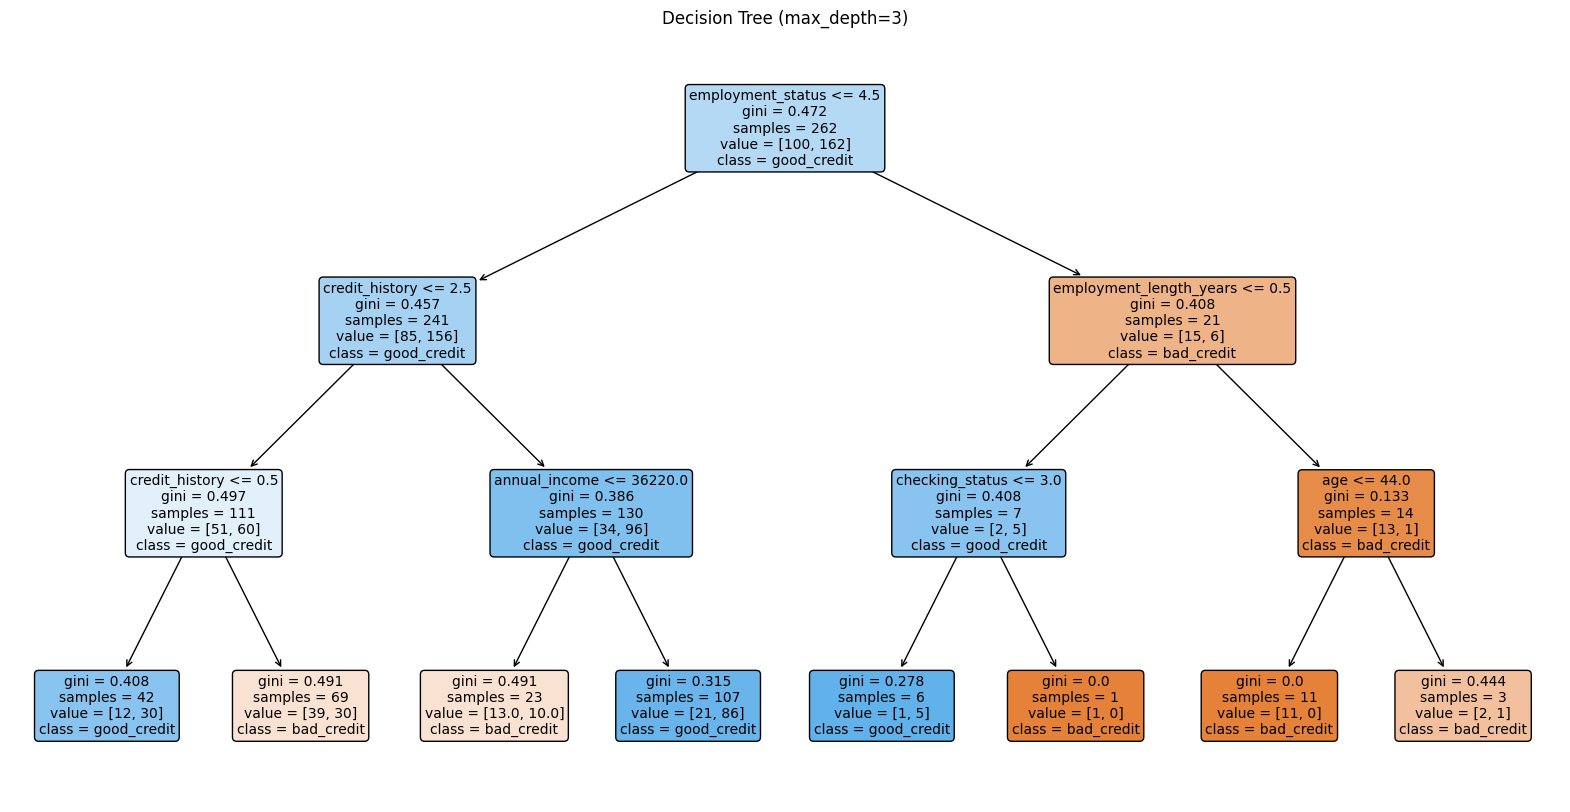

TREE 1 (max_depth=3) - Classification Report
              precision    recall  f1-score   support

  bad_credit       0.43      0.39      0.41        33
 good_credit       0.66      0.69      0.67        55

    accuracy                           0.58        88
   macro avg       0.54      0.54      0.54        88
weighted avg       0.57      0.58      0.58        88

TREE 2 (max_depth=10) - Classification Report
              precision    recall  f1-score   support

  bad_credit       0.48      0.39      0.43        33
 good_credit       0.67      0.75      0.71        55

    accuracy                           0.61        88
   macro avg       0.58      0.57      0.57        88
weighted avg       0.60      0.61      0.60        88

Top 10 Feature Importances (max_depth=3)
                    feature  importance
10           credit_history    0.357284
1             annual_income    0.209967
6         employment_status    0.205778
2   employment_length_years    0.157134
8           ch

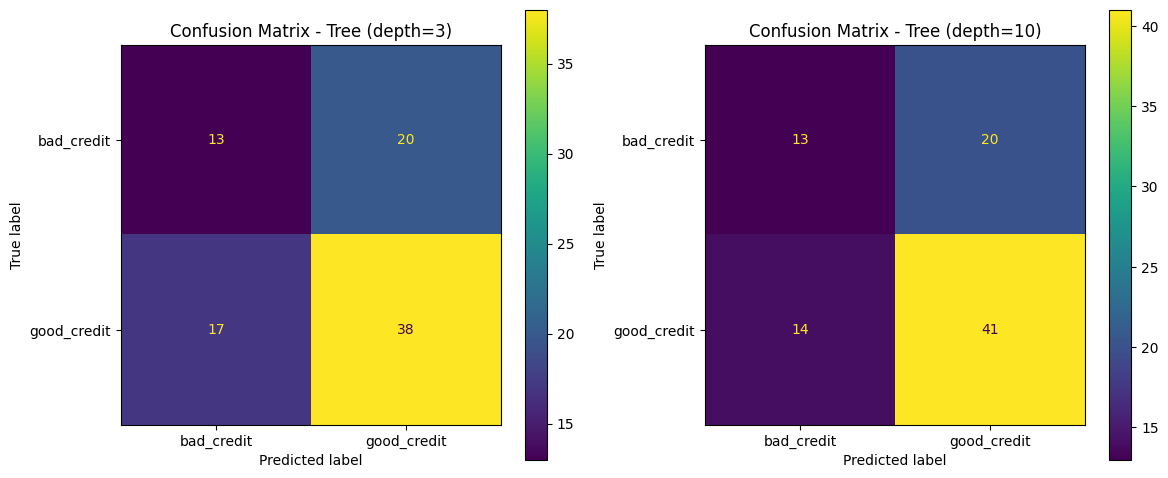

Tree (depth=3) accuracy:  0.5795
Tree (depth=10) accuracy: 0.6136


In [198]:
tree_shallow = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=3))
])

tree_deep = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=10))
])

tree_shallow.fit(X_train, y_train)
tree_deep.fit(X_train, y_train)

y_pred_shallow = tree_shallow.predict(X_test)
y_pred_deep = tree_deep.predict(X_test)

#Plot just tree 1 (max_depth=3)
feature_names = numeric_features + categorical_features
plt.figure(figsize=(20, 10))
plot_tree(
    tree_shallow.named_steps['classifier'],
    feature_names=feature_names,
    class_names=['bad_credit', 'good_credit'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=3)")
plt.show()

print("TREE 1 (max_depth=3) - Classification Report")
print(classification_report(y_test, y_pred_shallow))

print("TREE 2 (max_depth=10) - Classification Report")
print(classification_report(y_test, y_pred_deep))

importances = tree_shallow.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print("Top 10 Feature Importances (max_depth=3)")
print(feature_importance_df.head(10))

importances = tree_deep.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print("\nTop 10 Feature Importances (max_depth=10)")
print(feature_importance_df.head(10))

cm_shallow = confusion_matrix(y_test, y_pred_shallow)
cm_deep = confusion_matrix(y_test, y_pred_deep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_shallow, display_labels=['bad_credit', 'good_credit']).plot(ax=ax1)
ax1.set_title("Confusion Matrix - Tree (depth=3)")

ConfusionMatrixDisplay(confusion_matrix=cm_deep, display_labels=['bad_credit', 'good_credit']).plot(ax=ax2)
ax2.set_title("Confusion Matrix - Tree (depth=10)")

plt.tight_layout()
plt.show()

print(f"Tree (depth=3) accuracy:  {accuracy_score(y_test, y_pred_shallow):.4f}")
print(f"Tree (depth=10) accuracy: {accuracy_score(y_test, y_pred_deep):.4f}")

## Part 5: Train a Random Forest 

1. The Random Forest with 150 estimators did improve on the decision trees, with an accuracy of 65%, and slighty less off-diagonal elements in the confusion matrix.
2. Yes, they are very close 62% OOB vs 65% test accuracy. Close scores indicate the model is not overfittng - If OOB score was much higher than test accuracy, like 80% OOB vs 65% test, that would suggest the model memorized the training data but doesn't generalize well. The small gap suggests good generalization, the random forest is performing consistently on both out-of-bag samples which act like a validation set during training. ("https://scikit-learn.org/stable/auto_examples/ensemble/plot_ensemble_oob.html") The slight difference is expected - note that OOB score is typically a bit more optimistic since it uses slightly different data than the test set.
3. This dataset Your dataset has 352 good_credit (60%) and 232 bad_credit (40%) A "dummy" model that always predicts "good_credit" would achieve 60% accuracy. The 65% accuracy is only 5% better than random guessing - this is not good enough for loan decisions.

Accuracy is insufficient because loan approval is a cost-sensitive problem where false negatives (approving bad loans) are much more expensive than false positives (rejecting good customers). Examining precision, recall, and especially the confusion matrix to see which type of errors this model makes is better.

              precision    recall  f1-score   support

  bad_credit       0.59      0.43      0.49        56
 good_credit       0.68      0.80      0.73        84

    accuracy                           0.65       140
   macro avg       0.63      0.61      0.61       140
weighted avg       0.64      0.65      0.64       140

OOB Score:  0.6190476190476191


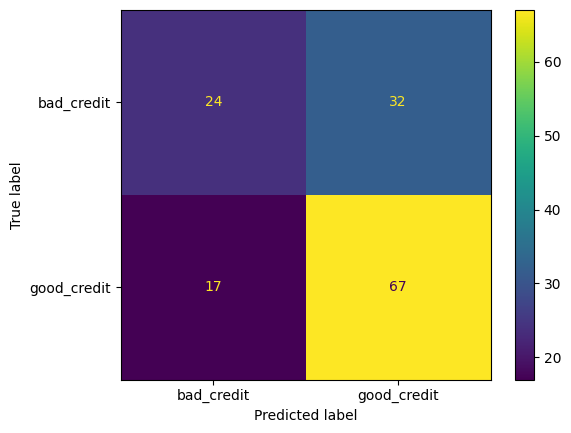


Top 10 Feature Importances
                    feature  importance
1             annual_income    0.138299
3               loan_amount    0.134923
0                       age    0.129212
2   employment_length_years    0.092523
4           duration_months    0.086729
10           credit_history    0.082911
7              loan_purpose    0.081567
8           checking_status    0.061670
9            savings_status    0.056565
5           missed_payments    0.055495


In [170]:
forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        criterion='gini', 
        max_features='sqrt',
        oob_score=True, 
        random_state=42))
])

forest.fit(X_train, y_train)
oob_score = forest.named_steps['classifier'].oob_score_
y_pred = forest.predict(X_test)

print(classification_report(y_test, y_pred))
print("OOB Score: ", oob_score)

cm = confusion_matrix(y_test, y_pred, labels=['bad_credit', 'good_credit'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad_credit', 'good_credit'])
disp.plot()
plt.show()

importances = forest.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print("\nTop 10 Feature Importances")
print(feature_importance_df.head(10))

## Part 6 and 7: Comparing Preprocessing Choices and Feature Importance

Comparing the two preprocessing approaches reveals a critical flaw in Version B. Version A used proper imputation, string normalization, and duplicate removal while intentionally dropping the leakage column final_decision_code, achieving a realistic 65% accuracy. Version B took a naive approach—dropping all rows with any suspicious values (losing 40% of the data) but keeping final_decision_code as a feature—which produced an artificially high 92% accuracy. The dramatic performance difference is explained by **data leakage**. The final_decision_code column has near-perfect correlation with the target variable: "auto_approved" corresponds to 100% good credit, "denied" to 88% bad credit, and "approved" to 91% good credit. In Version B, this single feature accounted for 42% of the model's feature importance, meaning the random forest essentially learned to ignore actual borrower features and simply read the pre-determined decision code.

Feature importance comparison further confirms the leakage problem. Version A's top features were legitimate borrower attributes: annual_income (14%), loan_amount (13%), age (13%), and employment_length_years (9%). Version B, however, placed final_decision_code at 42% importance, with all other features dropping to single-digit percentages. This demonstrates that when leakage is present, the model takes the "cheat" rather than learning meaningful patterns.

The practical implication is that Version B is completely useless for real-world loan decisions. In practice, you cannot know the final loan decision before evaluating the application—the model's 92% accuracy is an illusion created by hindsight bias. Version A's 65% accuracy, while modest (only 5% better than always guessing "good_credit"), represents honest, generalizable performance on truly predictive features. This highlights why careful preprocessing—specifically identifying and removing leakage columns—is essential before any modeling work.

*Personal Reflection on Parts 6, 7:*

This was a learning experience for me because it showed how easily bias can be included in AI and ML systems, because if the training data has leakage or other issues, and we naively assume accuracy is the best metric, our model can be completely useless in practice. For example, I was thinking about how often ML systems are used in actuarial pricing to price premiums for people with pre-existing conditions, and it makes me wonder how people get around issues like this in real practice. Maybe it all depends on your ethics or your company's ethics.

In [213]:
#Simply reloading the dataset for Version A.
df = pd.read_csv("messy_loan_risk_homework4.csv", dtype=str)

#Define suspicious values to remove
general_missing_tokens = {"", "?", "na", "n/a", "nan", "NaN", "null", "unknown"}

#Replace suspicious values with NaN, then drop those rows
df_clean = df.replace(general_missing_tokens, np.nan)
df_clean = df_clean.dropna()

# Remove applicant_id but keep final_decision_code to see if leakage occurs
df_clean = df_clean.drop(columns='applicant_id')

#Normalize text columns: strip whitespace and convert to lowercase
for col in df_clean.columns:
    #Only for string columns
    if df_clean[col].dtype == 'object': 
        df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()
for col in numeric_cols:
    df_clean[col] = df_clean[col].apply(clean_money_column)

print(f"Original shape: {df.shape}")
print(f"Shape after dropping rows with suspicious values: {df_clean.shape}")
df_clean.tail()

Original shape: (584, 15)
Shape after dropping rows with suspicious values: (350, 14)


,age,annual_income,employment_status,employment_length_years,loan_amount,loan_purpose,duration_months,checking_status,savings_status,credit_history,missed_payments,housing,final_decision_code,target
577,37.0,57048.0,employed,1.0,3017.0,business,36.0,low,none,critical,0.0,rent,denied,bad_credit
578,18.0,33159.0,employed,6.0,9954.0,debt consolidation,12.0,high,medium,existing paid,0.0,own,approved,good_credit
579,46.0,67000.0,employed,1.0,8942.0,debt consolidation,18.0,high,none,delayed previously,0.0,own,approved,good_credit
580,42.0,74491.0,employed,12.0,11158.0,education,6.0,none,low,all paid,1.0,own,approved,good_credit
581,59.0,144060.0,employed,5.0,7080.0,vacation,60.0,low,none,delayed previously,0.0,own,manual_review,bad_credit


In [226]:
#Identify which columns were used as features (exclude target and any leakage columns) then train_test_split
feature_cols_B = [col for col in df_clean.columns if col != "target" and col not in ["applicant_id"]]
X_train, X_test, y_train, y_test = train_test_split(df_clean[feature_cols_B], df_clean["target"], test_size=0.25, random_state=42)

In [227]:
numeric_features = ['age', 'annual_income', 'employment_length_years', 'loan_amount', 'duration_months', 'missed_payments']
categorical_features = [col for col in feature_cols if col not in numeric_features]

#Re-initialize the preprocessor to ensure the DataFrame shape is accurate across the whole notebook
preprocessor = ColumnTransformer(
    transformers=[
        #Pass numeric columns through as-is
        ('num', 'passthrough', numeric_features), 
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ]
)

version_B_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        criterion='gini', 
        max_features='sqrt',
        oob_score=True, 
        random_state=42))
])

              precision    recall  f1-score   support

  bad_credit       0.84      0.97      0.90        33
 good_credit       0.98      0.89      0.93        55

    accuracy                           0.92        88
   macro avg       0.91      0.93      0.92        88
weighted avg       0.93      0.92      0.92        88

OOB Score:  0.8893129770992366


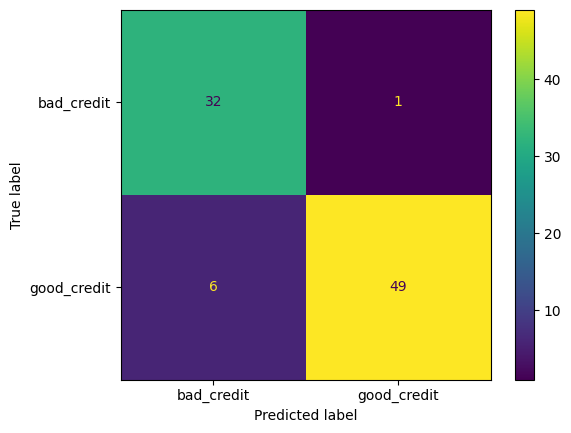


Top 10 Feature Importances for Version B
                    feature  importance
12      final_decision_code    0.422031
3   employment_length_years    0.080862
1             annual_income    0.078922
2         employment_status    0.058254
0                       age    0.051638
4               loan_amount    0.046936
7           checking_status    0.046517
10          missed_payments    0.045432
6           duration_months    0.044780
8            savings_status    0.040206
9            credit_history    0.036863
5              loan_purpose    0.032388
11                  housing    0.015170


In [228]:
version_B_forest.fit(X_train, y_train)
oob_score = version_B_forest.named_steps['classifier'].oob_score_
y_pred = version_B_forest.predict(X_test)

print(classification_report(y_test, y_pred))
print("OOB Score: ", oob_score)

cm = confusion_matrix(y_test, y_pred, labels=['bad_credit', 'good_credit'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad_credit', 'good_credit'])
disp.plot()
plt.show()

importances = version_B_forest.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols_B,
    'importance': importances
}).sort_values('importance', ascending=False)
print("\nTop 10 Feature Importances for Version B")
print(feature_importance_df.head(15))